# Red neuronal artificial para reconocer el tipo de un pokemon

En esta tarea ustedes deben diseñar, entrenar y evaluar un modelo de red neuronal con arquitectura convolucional para resolver el problema de reconocer el tipo de un pokemon en base a una imagen del mismo y a sus atributos. El principal desafio es el desbalance y poca cantidad de ejemplos en el dataset. 

A continuación se instancia el dataset y se itera para presentar algunos ejemplos:

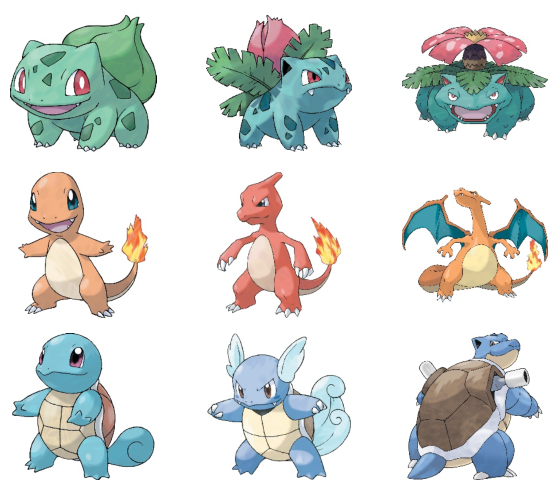

In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
from pokemon_utils import PokemonImages

dataset = PokemonImages('data/')

fig, ax = plt.subplots(3, 3, figsize=(7, 5), tight_layout=True)
for ax_, (image, label, name, attributes) in zip(ax.ravel(), dataset):
    ax_.imshow(image.permute(-2, -1, 0))
    ax_.axis('off');

Cada ejemplo tiene su imagen, su etiqueta, su nombre y sus atributos:

In [5]:
image, label, name, attributes = dataset[3]
type(image), image.shape, label, name, attributes

(torch.Tensor,
 torch.Size([3, 256, 256]),
 np.int64(6),
 'Charmander',
 tensor([ 0.6000,  8.5000, 39.0000, 52.0000, 43.0000, 65.0000]))

Se puede obtener el nombre de la clase con:

In [6]:
dataset.categories[label]

'Fire'

Y los atributos disponibles son:

In [7]:
dataset.attribute_names

['Height', 'Weight', 'HP', 'Attack', 'Defense', 'Speed']

La cantidad de ejemplos por clase es:

In [8]:
from collections import Counter
import pandas as pd
x = Counter(dataset.labels)
for key in sorted(x):
    print(f"{dataset.categories[key]}: {x[key]}")

Bug: 52
Dark: 20
Dragon: 13
Electric: 32
Fairy: 8
Fighting: 20
Fire: 34
Ghost: 18
Grass: 58
Ground: 26
Ice: 19
Normal: 80
Poison: 26
Psychic: 44
Rock: 32
Steel: 17
Water: 96


En lo que sigue utilice los siguientes conjuntos de entrenamiento (train) y prueba (test). 

In [9]:
import numpy as np
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(np.arange(len(dataset)),test_size=0.15, random_state=1234, 
                                       shuffle=True, stratify=dataset.labels)

train_dataset = Subset(dataset, train_idx)
test_dataset = Subset(dataset, test_idx)

### Definición del modelo

Defina e implemente un modelo apropiado para el problema. Justifique sus decisiones de diseño.

Antes de implementar el modelo para resolver el problema, tenemos que saber exactamente de qué tamaño son las imágenes (saber cuantos pixeles de alto y ancho tienen).

In [10]:
from pokemon_utils import PokemonImages

dataset_prueba = PokemonImages(data_path='data')

imagen_tensor, etiqueta, nombre, atributos = dataset_prueba[0]

print(f"Pokémon: {nombre}")
print(f"Dimensiones del tensor (Canales, Alto, Ancho): {imagen_tensor.shape}")

Pokémon: Bulbasaur
Dimensiones del tensor (Canales, Alto, Ancho): torch.Size([3, 256, 256])


Calcularemos el número para la variable *dimensiones_imagen_plana* de nuestro modelo:
- Los resultados arrojaron que tenemos un Alto x Ancho de 256 x 256
- Se aplicara una división por 4
- Finalmente se aplica la formula 32 * (Alto final) * (Ancho final)

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class WeightedFocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha  # Tensor con los pesos suavizados para cada clase
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # ce_loss aplica la entropía cruzada usando los pesos alpha
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        
        # pt es la probabilidad de acierto del modelo
        pt = torch.exp(-ce_loss)
        
        # Fórmula de Focal Loss ponderada por clase
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PokemonMultiModal(nn.Module):
    def __init__(self, num_atributos_numericos, num_clases):
        super().__init__()
        
        self.cnn = nn.Sequential(
        # Bloque 1 (256x256 -> 128x128)
        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
        nn.GroupNorm(num_groups=4, num_channels=16),  # en vez de nn.BatchNorm2d(16)        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        
        # Bloque 2 (128x128 -> 64x64)
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
        nn.GroupNorm(num_groups=8, num_channels=32),  # en vez de nn.BatchNorm2d(16)        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        
        # Bloque 3 (64x64 -> 32x32)
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
        nn.GroupNorm(num_groups=8, num_channels=64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # Bloque 4 (32x32 -> 16x16)
        nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
        nn.GroupNorm(num_groups=8, num_channels=64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        # --- CORRECCIÓN CLAVE: Global Average Pooling ---
        # Esto convierte el bloque de 64x16x16 a simplemente 64 valores (1 por canal)
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten() 
        )
        
        # Ojo: Asegúrate de tener definido el mlp y clasificador_final
        # Ejemplo si los tienes:
        self.mlp = nn.Sequential(
            nn.Linear(num_atributos_numericos, 16),
            nn.ReLU()
        )
        
        # Ahora la fusión es mucho más pequeña: 64 (de la CNN) + 16 (del MLP) = 80
        self.clasificador_final = nn.Sequential(
            nn.Dropout(p=0.4), # <-- Agregar DROPOUT para evitar sobreajuste
            nn.Linear(80, 32),
            nn.ReLU(),
            nn.Dropout(p=0.4), # <-- Agregar DROPOUT
            nn.Linear(32, num_clases)
        )

        # Ahora la imagen aplanada será mucho más manejable: 64 * 16 * 16 = 16,384
        nn.Flatten()


    def forward(self, imagen, atributos):
        # 1. Pasar la imagen por la CNN
        caracteristicas_visuales = self.cnn(imagen)
        
        # 2. Pasar los números por el MLP
        caracteristicas_numericas = self.mlp(atributos)
        
        # 3. Juntar ambas ramas (concatenar a lo largo de la dimensión 1)
        fusion = torch.cat((caracteristicas_visuales, caracteristicas_numericas), dim=1)
        
        # 4. Decisión final
        salida = self.clasificador_final(fusion)
        return salida

In [22]:
import numpy as np
import torch
from torch.utils.data import DataLoader

# 1. Usamos los datasets oficiales 
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 2. Solución al Desbalance: Calcular pesos por clase
# Extraemos todas las etiquetas de entrenamiento para contar cuántas hay de cada tipo
etiquetas_train = [train_dataset[i][1] for i in range(len(train_dataset))]
conteo_clases = np.bincount(etiquetas_train, minlength=(len(dataset.categories)))
print("número de clases:", len(dataset.categories))

# --- CORRECCIÓN: Suavizado con raíz cuadrada para evitar sesgo extremo ---
pesos_clases = 1.0 / (np.sqrt(conteo_clases) + 1e-5)
pesos_clases = pesos_clases / np.mean(pesos_clases)
pesos_tensor = torch.tensor(pesos_clases, dtype=torch.float32)

# 3. Solución a las escalas: Calcular Media y Desviación para Normalizar
# Extraemos los atributos numéricos para saber su escala real
atributos_train = torch.stack([train_dataset[i][3] for i in range(len(train_dataset))])
atr_mean = atributos_train.mean(dim=0)
atr_std = atributos_train.std(dim=0)

print("DataLoaders listos con el split oficial.")
print("Pesos para la pérdida calculados (para combatir el desbalance).")
print("Estadísticas de normalización calculadas.")


número de clases: 18
DataLoaders listos con el split oficial.
Pesos para la pérdida calculados (para combatir el desbalance).
Estadísticas de normalización calculadas.


### Entrenamiento del modelo

Entrene el modelo y muestre las curvas de aprendizaje. Justifique la elección de hiperparámetros.

**Elección y justificación de Hiperparámetros y Diseño de Entrenamiento:**

* **Función de Pérdida (`CrossEntropyLoss` con pesos):** Al ser un problema de clasificación multiclase (18 tipos elementales), esta es la función matemática estándar. Sin embargo, para atacar el principal desafío de la tarea (el desbalance de clases), calculamos la frecuencia inversa de cada tipo de Pokémon en el set de entrenamiento y se lo pasamos como parámetro `weight`. Esto hace que la red reciba una penalización mucho mayor si se equivoca en una clase minoritaria (ej. Hielo) que en una mayoritaria (ej. Agua).
* **Normalización Tabular (Prevención de Data Leakage):** Los 6 atributos numéricos tienen escalas muy distintas (ej. Stats de 200 vs Alturas de 1.5m). Para estabilizar el aprendizaje de la rama MLP, estandarizamos estos datos restando la media y dividiendo por la desviación estándar. Es vital destacar que estos valores estadísticos se calcularon **exclusivamente con el set de entrenamiento**, y esos mismos valores se aplicaron al set de prueba para evitar "fuga de datos" (que el modelo adquiera información del set de evaluación antes de tiempo).
* **Optimizador (`Adam`, lr=0.001):** Ideal para arquitecturas multimodales porque adapta dinámicamente la tasa de aprendizaje para cada peso de la red, evitando estancamientos. El *Learning Rate* de 0.001 es un inicio conservador y estable.


In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn
torch.set_num_threads(4)
device = torch.device("cpu")
# 1. Instanciamos el modelo multimodal
modelo_final = PokemonMultiModal(
    num_atributos_numericos=6, 
    num_clases=len(dataset.categories)
).to(device=device, memory_format=torch.channels_last)

# 2. Configuramos la pérdida con CrossEntropyLoss y los pesos suavizados
criterio = nn.CrossEntropyLoss(weight=pesos_tensor)

optimizador = optim.Adam(modelo_final.parameters(), lr=0.0005, weight_decay=1e-4)
epocas = 30

loss_historial = []
atr_mean = atr_mean.to(device)
atr_std = atr_std.to(device)

print(f"Iniciando entrenamiento BASE por {epocas} épocas...")

for epoca in range(epocas):
    modelo_final.train()
    loss_acumulada = 0.0
    
    for imagenes, etiquetas, nombres, atributos in train_loader:
        imagenes = imagenes.to(device=device, memory_format=torch.channels_last)
        etiquetas = etiquetas.to(device)
        atributos = atributos.to(device)
        
        # Restamos la media y dividimos por la desviación estándar
        atributos_normalizados = (atributos - atr_mean) / (atr_std + 1e-7)
        
        optimizador.zero_grad()
        
        # Usamos los atributos normalizados
        predicciones = modelo_final(imagenes, atributos_normalizados)
        loss = criterio(predicciones, etiquetas)
        
        loss.backward()
        optimizador.step()
        
        loss_acumulada += loss.item()
        
    loss_promedio = loss_acumulada / len(train_loader)
    loss_historial.append(loss_promedio)
    
    if (epoca + 1) % 5 == 0:
        print(f"Época [{epoca+1}/{epocas}] | Loss: {loss_promedio:.4f}")
        
print("¡Entrenamiento finalizado!")


Iniciando entrenamiento BASE por 30 épocas...
Época [5/30] | Loss: 2.8350
Época [10/30] | Loss: 2.8186
Época [15/30] | Loss: 2.7443
Época [20/30] | Loss: 2.6990
Época [25/30] | Loss: 2.6039
Época [30/30] | Loss: 2.5335
¡Entrenamiento finalizado!


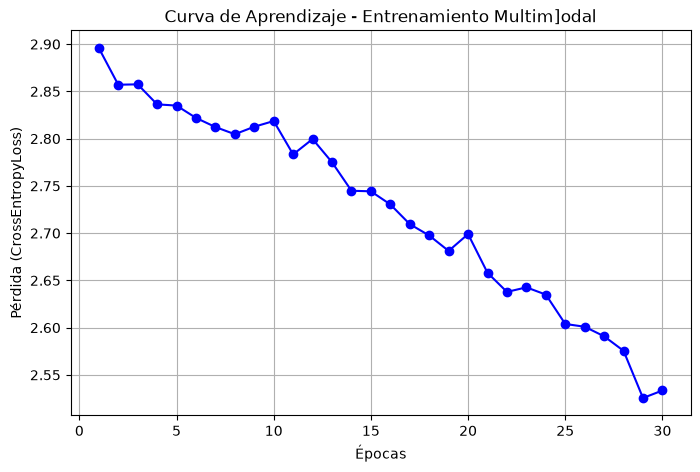

In [24]:
import matplotlib.pyplot as plt

# Generar la Curva de Aprendizaje
plt.figure(figsize=(8, 5))
plt.plot(range(1, epocas + 1), loss_historial, marker='o', linestyle='-', color='b')
plt.title("Curva de Aprendizaje - Entrenamiento Multim]odal")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (CrossEntropyLoss)")
plt.grid(True)
plt.show()

### Evaluación del modelo

Evalúe el modelo en el conjunto de prueba usando matriz de confusión y reporte de clasificación. Discuta los resultados.

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

         Bug       0.40      0.25      0.31         8
        Dark       0.00      0.00      0.00         3
      Dragon       0.00      0.00      0.00         2
    Electric       0.00      0.00      0.00         5
       Fairy       0.00      0.00      0.00         1
    Fighting       0.00      0.00      0.00         3
        Fire       0.22      1.00      0.36         5
       Ghost       0.00      0.00      0.00         3
       Grass       0.00      0.00      0.00         9
      Ground       0.00      0.00      0.00         4
         Ice       0.00      0.00      0.00         3
      Normal       0.17      0.17      0.17        12
      Poison       0.00      0.00      0.00         4
     Psychic       0.00      0.00      0.00         7
        Rock       0.25      0.20      0.22         5
       Steel       0.50      0.50      0.50         2
       Water       0.24      0.64      0.35     

/home/shutuppls/Documentos/TareasIA-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/shutuppls/Documentos/TareasIA-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/shutuppls/Documentos/TareasIA-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

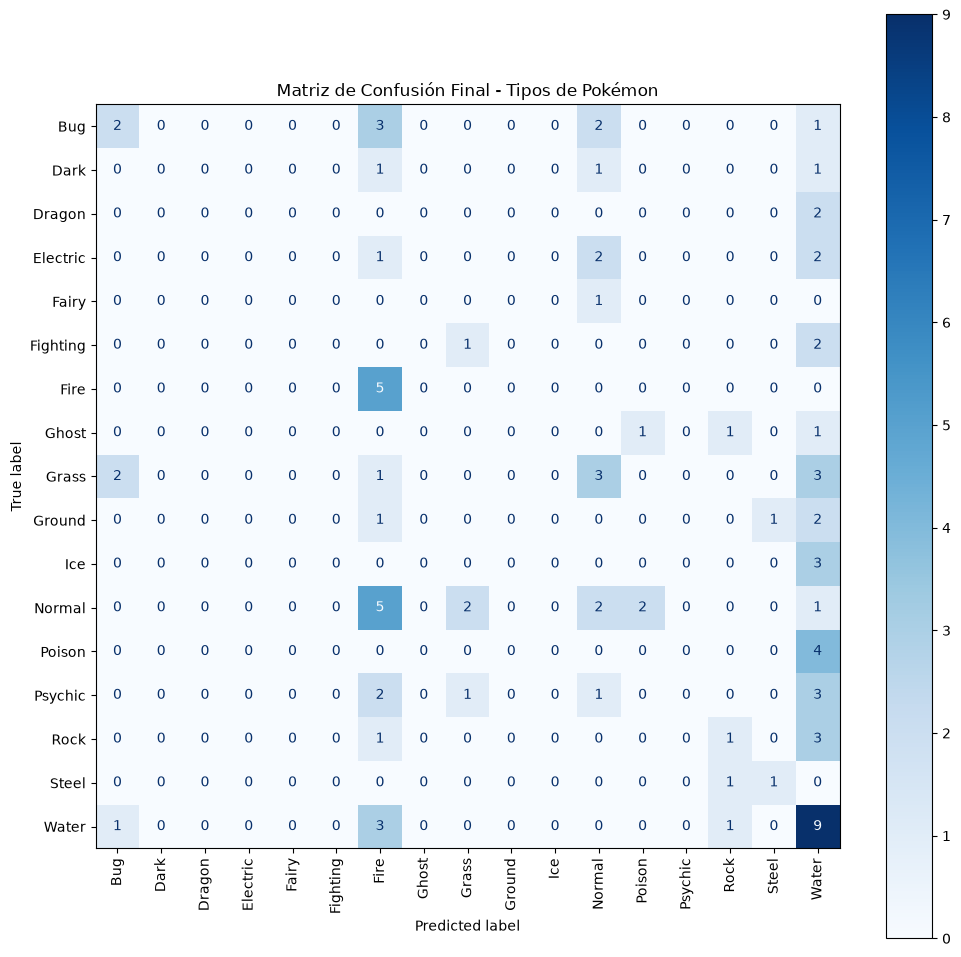

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# ==========================================
# EVALUACIÓN DEL MODELO Y RECOLECCIÓN DE PREDICCIONES
# ==========================================
modelo_final.eval() # Ponemos el modelo en modo evaluación (desactiva Dropout/BatchNorm)
y_real = []
y_pred = []

# No necesitamos calcular gradientes en la evaluación
with torch.no_grad():
    for imagenes, etiquetas, nombres, atributos in test_loader:
        imagenes = imagenes.to(device)
        
        # Mismo procedimiento de normalización que usamos en el entrenamiento
        atributos = atributos.to(device)
        atributos_normalizados = (atributos - atr_mean) / (atr_std + 1e-7)
        
        # Hacemos la predicción
        salidas = modelo_final(imagenes, atributos_normalizados)
        
        # Nos quedamos con la clase que tenga mayor probabilidad
        _, predicciones = torch.max(salidas, 1)
        
        # Guardamos las verdaderas y las predichas en nuestras listas
        y_real.extend(etiquetas.cpu().numpy())
        y_pred.extend(predicciones.cpu().numpy())
# ==========================================

# Generar el reporte de clasificación usando las categorías de tu dataset
# Solo le pasamos las etiquetas únicas que realmente se predijeron o existían en y_real/y_pred
etiquetas_presentes = sorted(list(set(y_real).union(set(y_pred))))
nombres_etiquetas = [dataset.categories[i] for i in etiquetas_presentes]

print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_real, y_pred, labels=etiquetas_presentes, target_names=nombres_etiquetas))

# Generar la Matriz de Confusión Visual
cm = confusion_matrix(y_real, y_pred, labels=etiquetas_presentes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_etiquetas)

fig, ax = plt.subplots(figsize=(12, 12)) # Agrandamos la figura porque son muchas clases
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title("Matriz de Confusión Final - Tipos de Pokémon")
plt.show()


### Análisis de errores

Analice algunos ejemplos mal clasificados y comente lo que observa.

Total de errores en el Test Set: 72 de 90


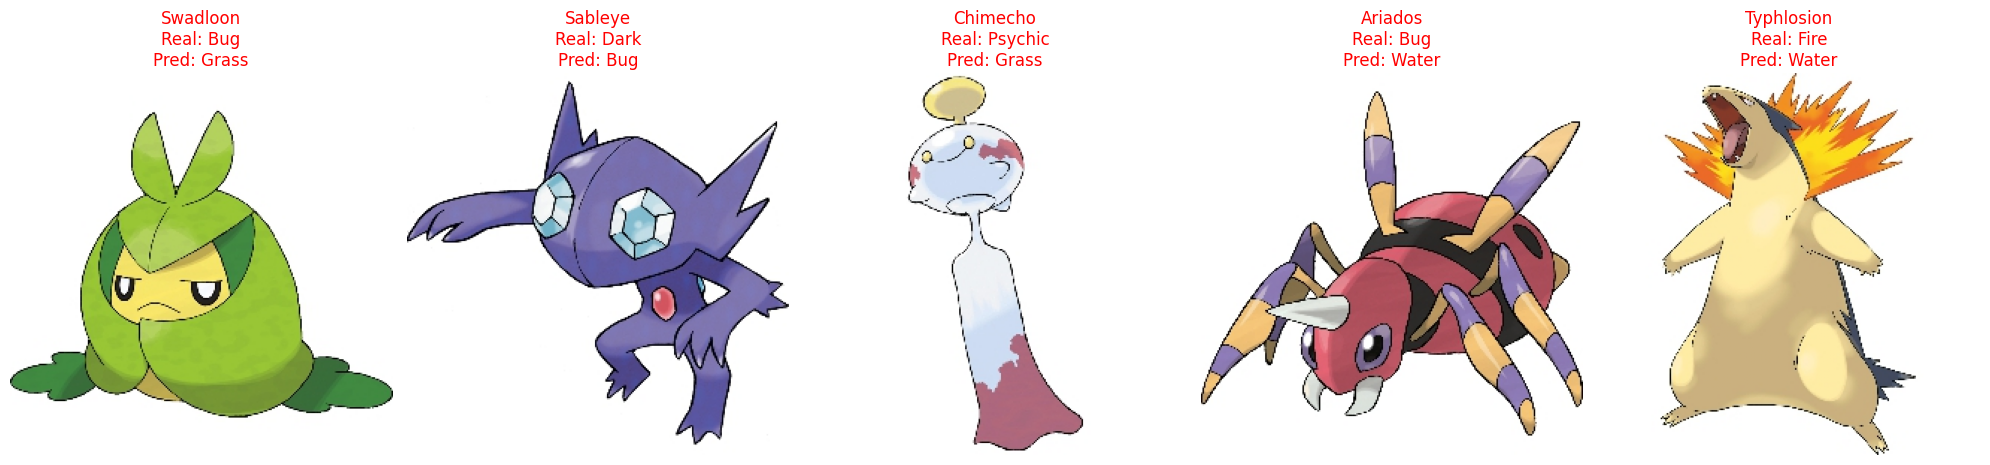

In [54]:
import numpy as np

# 1. Encontrar los índices donde el modelo falló
errores_idx = np.where(np.array(y_real) != np.array(y_pred))[0]
print(f"Total de errores en el Test Set: {len(errores_idx)} de {len(y_real)}")

# 2. Visualizar los primeros 5 ejemplos mal clasificados
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, idx in enumerate(errores_idx[:5]): 
    # Extraer los datos originales del test_dataset
    imagen_tensor, etiqueta_real, nombre, atributos = test_dataset[idx]
    prediccion = y_pred[idx]
    
    # Obtener el texto del tipo real y el predicho
    tipo_real = dataset.categories[etiqueta_real]
    tipo_predicho = dataset.categories[prediccion]
    
    # Las imágenes en PyTorch tienen shape (Canales, Alto, Ancho)
    # plt.imshow espera (Alto, Ancho, Canales), por lo que usamos permute()
    img_mostrar = imagen_tensor.permute(-2, -1, 0).cpu().numpy()
    
    # Si usaste alguna normalización con media y desviación estándar, 
    # la imagen puede verse con colores raros, pero es normal.
    axes[i].imshow(img_mostrar)
    axes[i].set_title(f"{nombre}\nReal: {tipo_real}\nPred: {tipo_predicho}", fontsize=12, color='red')
    axes[i].axis('off')

plt.tight_layout()
plt.show()


### Aumentación de datos

Implemente un esquema de aumentación aleatoria de datos y compare los resultados con y sin aumentación.

In [26]:
import torchvision.transforms as T

train_transforms = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    T.RandomResizedCrop(size=(256, 256), scale=(0.95, 1.0)),
])

class AugmentedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label, name, attributes = self.subset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label, name, attributes

train_dataset_aug = AugmentedSubset(train_dataset, transform=train_transforms)
train_loader = DataLoader(train_dataset_aug, batch_size=16, shuffle=True)

In [27]:
import torch
import torch.optim as optim
import torch.nn as nn
torch.set_num_threads(4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instanciamos el modelo multimodal
modelo_final = PokemonMultiModal(
    num_atributos_numericos=6, 
    num_clases=len(dataset.categories)
).to(device=device, memory_format=torch.channels_last)

# Configuramos la pérdida con CrossEntropyLoss y los pesos suavizados
criterio = nn.CrossEntropyLoss(weight=pesos_tensor)
optimizador = optim.Adam(modelo_final.parameters(), lr=0.0005, weight_decay=1e-4)
epocas = 30

loss_historial = []
atr_mean = atr_mean.to(device)
atr_std = atr_std.to(device)

print(f"Iniciando entrenamiento BASE por {epocas} épocas...")

for epoca in range(epocas):
    modelo_final.train()
    loss_acumulada = 0.0
    
    for imagenes, etiquetas, nombres, atributos in train_loader:
        imagenes = imagenes.to(device=device, memory_format=torch.channels_last)
        etiquetas = etiquetas.to(device)
        atributos = atributos.to(device)
        
        # Restamos la media y dividimos por la desviación estándar
        atributos_normalizados = (atributos - atr_mean) / (atr_std + 1e-7)
        
        optimizador.zero_grad()
        
        # Usamos los atributos normalizados
        predicciones = modelo_final(imagenes, atributos_normalizados)
        loss = criterio(predicciones, etiquetas)
        
        loss.backward()
        optimizador.step()
        
        loss_acumulada += loss.item()
        
    loss_promedio = loss_acumulada / len(train_loader)
    loss_historial.append(loss_promedio)
    
    if (epoca + 1) % 5 == 0:
        print(f"Época [{epoca+1}/{epocas}] | Loss: {loss_promedio:.4f}")
        
print("¡Entrenamiento finalizado!")


Iniciando entrenamiento BASE por 30 épocas...
Época [5/30] | Loss: 2.8447
Época [10/30] | Loss: 2.7771
Época [15/30] | Loss: 2.7273
Época [20/30] | Loss: 2.6627
Época [25/30] | Loss: 2.5836
Época [30/30] | Loss: 2.5241
¡Entrenamiento finalizado!


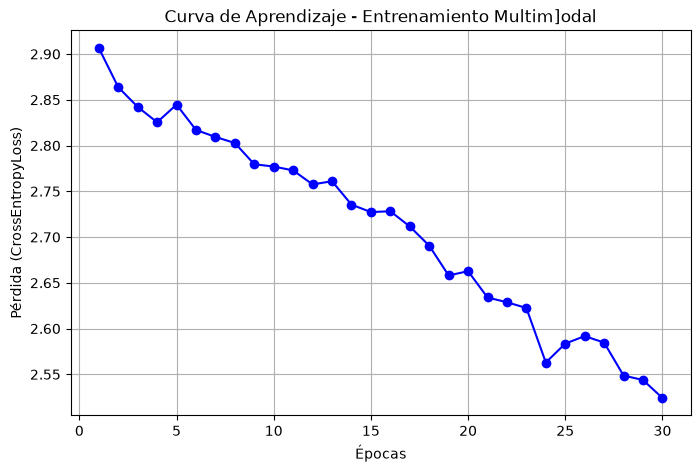

In [28]:
import matplotlib.pyplot as plt

# Generar la Curva de Aprendizaje
plt.figure(figsize=(8, 5))
plt.plot(range(1, epocas + 1), loss_historial, marker='o', linestyle='-', color='b')
plt.title("Curva de Aprendizaje - Entrenamiento Multim]odal")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (CrossEntropyLoss)")
plt.grid(True)
plt.show()

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

         Bug       0.25      0.25      0.25         8
        Dark       0.00      0.00      0.00         3
      Dragon       0.00      0.00      0.00         2
    Electric       0.00      0.00      0.00         5
       Fairy       0.00      0.00      0.00         1
    Fighting       0.00      0.00      0.00         3
        Fire       0.17      1.00      0.29         5
       Ghost       0.00      0.00      0.00         3
       Grass       0.25      0.11      0.15         9
      Ground       0.00      0.00      0.00         4
         Ice       0.00      0.00      0.00         3
      Normal       0.17      0.08      0.11        12
      Poison       0.17      0.25      0.20         4
     Psychic       0.00      0.00      0.00         7
        Rock       0.00      0.00      0.00         5
       Steel       0.00      0.00      0.00         2
       Water       0.27      0.64      0.38     

/home/shutuppls/Documentos/TareasIA-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/shutuppls/Documentos/TareasIA-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/shutuppls/Documentos/TareasIA-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

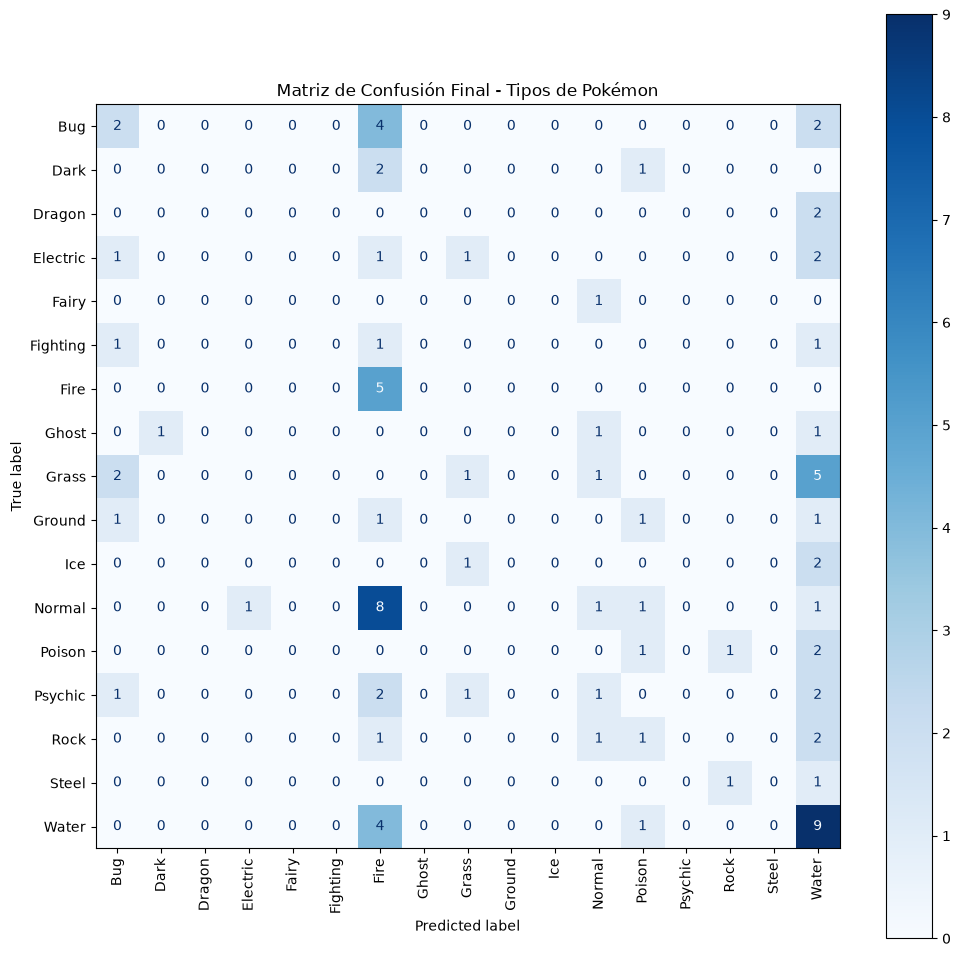

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# ==========================================
# EVALUACIÓN DEL MODELO Y RECOLECCIÓN DE PREDICCIONES
# ==========================================
modelo_final.eval() # Ponemos el modelo en modo evaluación (desactiva Dropout/BatchNorm)
y_real = []
y_pred = []

# No necesitamos calcular gradientes en la evaluación
with torch.no_grad():
    for imagenes, etiquetas, nombres, atributos in test_loader:
        imagenes = imagenes.to(device)
        
        # Mismo procedimiento de normalización que usamos en el entrenamiento
        atributos = atributos.to(device)
        atributos_normalizados = (atributos - atr_mean) / (atr_std + 1e-7)
        
        # Hacemos la predicción
        salidas = modelo_final(imagenes, atributos_normalizados)
        
        # Nos quedamos con la clase que tenga mayor probabilidad
        _, predicciones = torch.max(salidas, 1)
        
        # Guardamos las verdaderas y las predichas en nuestras listas
        y_real.extend(etiquetas.cpu().numpy())
        y_pred.extend(predicciones.cpu().numpy())
# ==========================================

# Generar el reporte de clasificación usando las categorías de tu dataset
# Solo le pasamos las etiquetas únicas que realmente se predijeron o existían en y_real/y_pred
etiquetas_presentes = sorted(list(set(y_real).union(set(y_pred))))
nombres_etiquetas = [dataset.categories[i] for i in etiquetas_presentes]

print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_real, y_pred, labels=etiquetas_presentes, target_names=nombres_etiquetas))

# Generar la Matriz de Confusión Visual
cm = confusion_matrix(y_real, y_pred, labels=etiquetas_presentes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_etiquetas)

fig, ax = plt.subplots(figsize=(12, 12)) # Agrandamos la figura porque son muchas clases
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title("Matriz de Confusión Final - Tipos de Pokémon")
plt.show()


Total de errores en el Test Set: 71 de 90


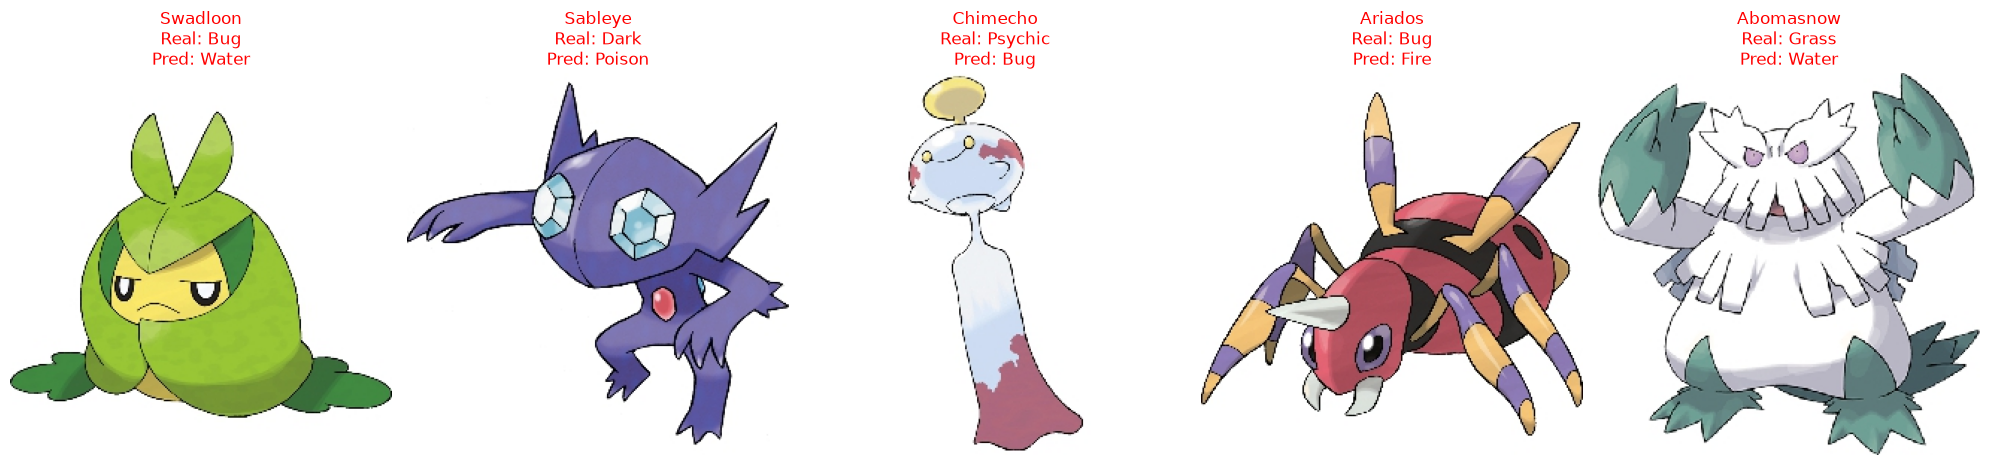

In [30]:
import numpy as np

# 1. Encontrar los índices donde el modelo falló
errores_idx = np.where(np.array(y_real) != np.array(y_pred))[0]
print(f"Total de errores en el Test Set: {len(errores_idx)} de {len(y_real)}")

# 2. Visualizar los primeros 5 ejemplos mal clasificados
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, idx in enumerate(errores_idx[:5]): 
    # Extraer los datos originales del test_dataset
    imagen_tensor, etiqueta_real, nombre, atributos = test_dataset[idx]
    prediccion = y_pred[idx]
    
    # Obtener el texto del tipo real y el predicho
    tipo_real = dataset.categories[etiqueta_real]
    tipo_predicho = dataset.categories[prediccion]
    
    # Las imágenes en PyTorch tienen shape (Canales, Alto, Ancho)
    # plt.imshow espera (Alto, Ancho, Canales), por lo que usamos permute()
    img_mostrar = imagen_tensor.permute(-2, -1, 0).cpu().numpy()
    
    # Si usaste alguna normalización con media y desviación estándar, 
    # la imagen puede verse con colores raros, pero es normal.
    axes[i].imshow(img_mostrar)
    axes[i].set_title(f"{nombre}\nReal: {tipo_real}\nPred: {tipo_predicho}", fontsize=12, color='red')
    axes[i].axis('off')

plt.tight_layout()
plt.show()


### Uso de un Modelo Pre-entrenado (Transfer Learning)

Como alternativa a la arquitectura multimodal construida desde cero, implementamos un modelo basado en una red pre-entrenada (ResNet) extrayendo sus características y adaptando una nueva cabecera de clasificación para nuestro problema específico. 

A diferencia de nuestra arquitectura multimodal construida desde cero, en este experimento de Transfer Learning decidimos prescindir de los atributos numéricos (rama MLP). El objetivo de este enfoque es evaluar la capacidad predictiva del modelo basándose exclusivamente en la extracción de características visuales puras de la ResNet18.

Durante la fase de experimentación y diseño de este modelo, realizamos varias pruebas para evitar el sobreajuste y estabilizar el aprendizaje:

* **Ajuste de Dropout:** Se iteró subiendo la tasa de *Dropout* de la capa final hasta un máximo de 0.8, punto en el cual la red sufrió una pérdida masiva de información y dejó de aprender. Al reducir este valor de forma progresiva, encontramos que el límite óptimo de regularización se encuentra en **0.4**. Valores inferiores a este no mostraron ninguna mejora en el conjunto de validación.

#### Proceso de Aprendizaje con Dropout 0.8
![Aprendizaje Dropout 0.8](img/drop-08.png)

* **Capas Intermedias:** Se probó añadir profundidad al clasificador insertando capas `Linear` y `ReLU` adicionales. Sin embargo, esto no se tradujo en una mejor extracción de características. Por el contrario, añadió un muy leve "ruido" a la curva de validación, por lo que se optó por un clasificador más directo.

#### Curvas de Aprendizaje con Dropout 0.4 y capas intermedias
![Curva de Aprendizaje Dropout 0.4 con capas](img/drop-04-capas.png)

* **Memorización:** A través de las curvas de aprendizaje, notamos que el modelo deja de generalizar a partir de la época 15 aproximadamente, momento en el que empieza a memorizar el conjunto de entrenamiento. Para aprovechar esto, implementamos el guardado automático de los pesos en la época con la mejor pérdida de validación.

#### Curvas de Aprendizaje con Dropout 0.4 y sin capas intermedias
![Curva de Aprendizaje Dropout 0.4 sin capas](img/drop-04-no-capas.png)

### Enfoque Final: Transfer Learning (ResNet18) + Aumentación de Datos

Debido al diseño secuencial de nuestro pipeline de experimentación en este notebook, el modelo pre-entrenado se beneficia directamente del esquema de **Aumentación Aleatoria de Datos** (`train_dataset_aug`) definido en la sección anterior.

Por lo tanto, el experimento definitivo que queda inmortalizado en esta sección representa nuestro modelo híbrido más completo: **Extracción de características pre-entrenadas robustecida mediante variabilidad sintética de datos**. Aunque no sea precisamente la mejor etapa que hemos cruzado.


In [12]:
import torch.nn as nn
import torchvision.models as models

class PokemonPretrainedResNet(nn.Module):
    def __init__(self, num_clases, freeze_backbone=True):
        super().__init__()
        
        # Cargamos ResNet18 con sus pesos pre-entrenados en ImageNet
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Si no congelamos estas capas el modelo se sobreajustaba muy rapido.
        # Al parecer tiene relación con el dataset pequeño vs lo grande del modelo.
        if freeze_backbone:
            for param in self.resnet.parameters():
                param.requires_grad = False
        
        # ResNet18 termina en una capa llamada "fc" (Fully Connected). 
        # Averiguamos cuántas características genera antes de clasificar:
        num_features = self.resnet.fc.in_features
        
        # Reemplazamos esa capa "fc" por un nuevo clasificador adaptado a las 18 clases.
        # Estas son las nuevas capaz que se entrenarán desde 0
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.4), # Dropout para evitar que memorice el set de entrenamiento
            nn.Linear(num_features, num_clases)
        )

    def forward(self, imagen):
        # Pasamos la imagen directamente a través de toda la estructura de ResNet
        return self.resnet(imagen)

### Entrenamiento de la ResNet

In [16]:
import torch.optim as optim
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instanciamos el modelo
modelo_final = PokemonPretrainedResNet(num_clases=len(dataset.categories), freeze_backbone=True).to(device)
pesos_tensor = pesos_tensor.to(device)
criterio = nn.CrossEntropyLoss(weight=pesos_tensor)

# Al usar Adam, solo le pasamos los parámetros que requieren gradiente
parametros_a_entrenar = [p for p in modelo_final.parameters() if p.requires_grad]
optimizador = optim.Adam(parametros_a_entrenar, lr=0.001, weight_decay=1e-4)

epocas = 30
intervalo_registro = 1 

loss_train_historial = []
loss_val_historial = []
epocas_grafico = []

print(f"Iniciando entrenamiento con RESNET PRE-ENTRENADA por {epocas} épocas...")

mejor_loss_val = float('inf')

for epoca in range(epocas):
    # FASE 1: ENTRENAMIENTO
    modelo_final.train()
    loss_train_acumulada = 0.0
    
    for imagenes, etiquetas, nombres, atributos in train_loader:
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)
        
        optimizador.zero_grad()
        predicciones = modelo_final(imagenes) # Funciona igual porque solo pide la imagen
        loss = criterio(predicciones, etiquetas)
        
        loss.backward()
        optimizador.step()
        
        loss_train_acumulada += loss.item()
        
    loss_train_promedio = loss_train_acumulada / len(train_loader)
    
    # FASE 2: VALIDACIÓN
    if (epoca + 1) % intervalo_registro == 0:
        modelo_final.eval()
        loss_val_acumulada = 0.0
        
        with torch.no_grad(): 
            for imagenes_val, etiquetas_val, _, _ in test_loader:
                imagenes_val = imagenes_val.to(device)
                etiquetas_val = etiquetas_val.to(device)
                
                predicciones_val = modelo_final(imagenes_val)
                loss_val = criterio(predicciones_val, etiquetas_val)
                loss_val_acumulada += loss_val.item()
                
        loss_val_promedio = loss_val_acumulada / len(test_loader)
        
        loss_train_historial.append(loss_train_promedio)
        loss_val_historial.append(loss_val_promedio)
        epocas_grafico.append(epoca + 1)
        
        print(f"Época [{epoca+1}/{epocas}] | Train Loss: {loss_train_promedio:.4f} | Val Loss: {loss_val_promedio:.4f}")

        if loss_val_promedio < mejor_loss_val:
            mejor_loss_val = loss_val_promedio
            torch.save(modelo_final.state_dict(), 'mejor_modelo_pokemon.pth')
            print("  --> ¡Mejora detectada! Modelo guardado.")

print("¡Entrenamiento con modelo pre-entrenado finalizado!")

Iniciando entrenamiento con RESNET PRE-ENTRENADA por 30 épocas...
Época [1/30] | Train Loss: 3.0575 | Val Loss: 2.6733
  --> ¡Mejora detectada! Modelo guardado.
Época [2/30] | Train Loss: 2.6569 | Val Loss: 2.5150
  --> ¡Mejora detectada! Modelo guardado.
Época [3/30] | Train Loss: 2.5027 | Val Loss: 2.4102
  --> ¡Mejora detectada! Modelo guardado.
Época [4/30] | Train Loss: 2.2629 | Val Loss: 2.3135
  --> ¡Mejora detectada! Modelo guardado.
Época [5/30] | Train Loss: 2.1656 | Val Loss: 2.3035
  --> ¡Mejora detectada! Modelo guardado.
Época [6/30] | Train Loss: 2.1023 | Val Loss: 2.2352
  --> ¡Mejora detectada! Modelo guardado.
Época [7/30] | Train Loss: 1.9945 | Val Loss: 2.1826
  --> ¡Mejora detectada! Modelo guardado.
Época [8/30] | Train Loss: 1.9328 | Val Loss: 2.1433
  --> ¡Mejora detectada! Modelo guardado.
Época [9/30] | Train Loss: 1.7943 | Val Loss: 2.1484
Época [10/30] | Train Loss: 1.7875 | Val Loss: 2.1401
  --> ¡Mejora detectada! Modelo guardado.
Época [11/30] | Train Los

### Curvas de Aprendizaje

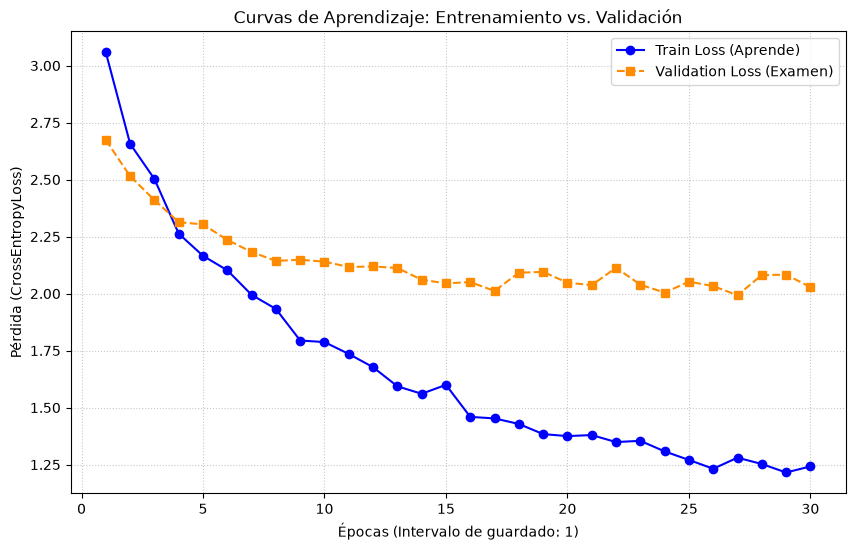

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Trazamos la línea de entrenamiento (Azul)
plt.plot(epocas_grafico, loss_train_historial, marker='o', linestyle='-', color='blue', label='Train Loss (Aprende)')

# Trazamos la línea de validación (Naranja/Roja)
plt.plot(epocas_grafico, loss_val_historial, marker='s', linestyle='--', color='darkorange', label='Validation Loss (Examen)')

plt.title("Curvas de Aprendizaje: Entrenamiento vs. Validación")
plt.xlabel(f"Épocas (Intervalo de guardado: {intervalo_registro})")
plt.ylabel("Pérdida (CrossEntropyLoss)")

# Añadimos la leyenda para identificar qué color es cuál
plt.legend(loc="upper right")
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

### Evaluación del Modelo

Evaluando el modelo en el set de prueba...

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

         Bug       0.62      0.62      0.62         8
        Dark       0.00      0.00      0.00         3
      Dragon       0.00      0.00      0.00         2
    Electric       0.60      0.60      0.60         5
       Fairy       0.33      1.00      0.50         1
    Fighting       0.67      0.67      0.67         3
        Fire       0.29      0.40      0.33         5
      Flying       0.00      0.00      0.00         0
       Ghost       0.50      0.67      0.57         3
       Grass       0.55      0.67      0.60         9
      Ground       0.00      0.00      0.00         4
         Ice       0.25      0.33      0.29         3
      Normal       0.40      0.33      0.36        12
      Poison       0.25      0.25      0.25         4
     Psychic       0.00      0.00      0.00         7
        Rock       0.33      0.20      0.25         5
    

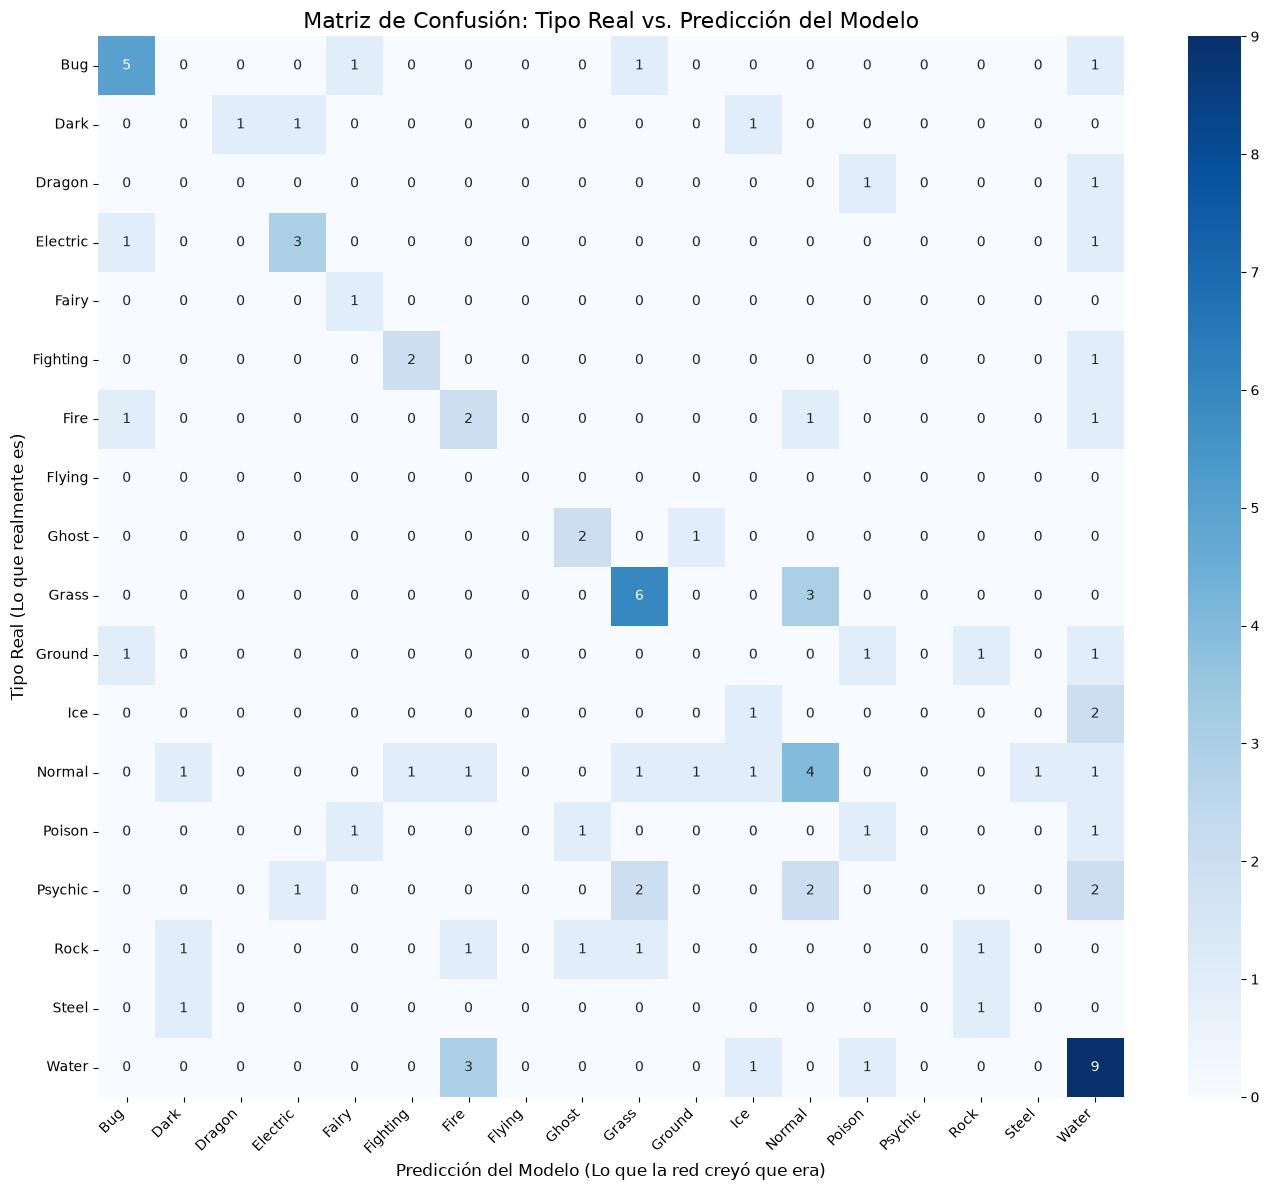

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

# Recopilar las predicciones del conjunto de prueba
modelo_final.eval() # Asegurarnos de que el modelo esté en modo evaluación
y_reales = []
y_predicciones = []

print("Evaluando el modelo en el set de prueba...")

with torch.no_grad():
    for imagenes, etiquetas, _, _ in test_loader:
        imagenes = imagenes.to(device)
        
        # Obtenemos las predicciones crudas
        salidas = modelo_final(imagenes)
        
        # Nos quedamos con la clase que tenga la probabilidad más alta (argmax)
        _, prediccion = torch.max(salidas, 1)
        
        # Guardamos las etiquetas reales y las predicciones en listas
        y_reales.extend(etiquetas.cpu().numpy())
        y_predicciones.extend(prediccion.cpu().numpy())

# Obtener los nombres de las clases en orden
nombres_clases = [dataset.categories[i] for i in range(len(dataset.categories))]

# ==========================================
# PARTE A: LAS 4 MÉTRICAS (Reporte de Clasificación)
# ==========================================
print("\n--- REPORTE DE CLASIFICACIÓN ---")
# Agregamos labels=range(len(nombres_clases)) para forzar las 18 clases
print(classification_report(y_reales, 
                            y_predicciones, 
                            target_names=nombres_clases, 
                            labels=range(len(nombres_clases)), 
                            zero_division=0))


# ==========================================
# PARTE B: EL MAPA (Matriz de Confusión)
# ==========================================
# También agregamos labels aquí para garantizar la cuadrícula de 18x18
cm = confusion_matrix(y_reales, y_predicciones, labels=range(len(nombres_clases)))

# La dibujamos usando un mapa de calor (Heatmap)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases, 
            yticklabels=nombres_clases)

plt.title('Matriz de Confusión: Tipo Real vs. Predicción del Modelo', fontsize=16)
plt.xlabel('Predicción del Modelo (Lo que la red creyó que era)', fontsize=12)
plt.ylabel('Tipo Real (Lo que realmente es)', fontsize=12)

plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

### Análisis de Errores

Total de errores (ResNet Pre-entrenada): 53 de 90


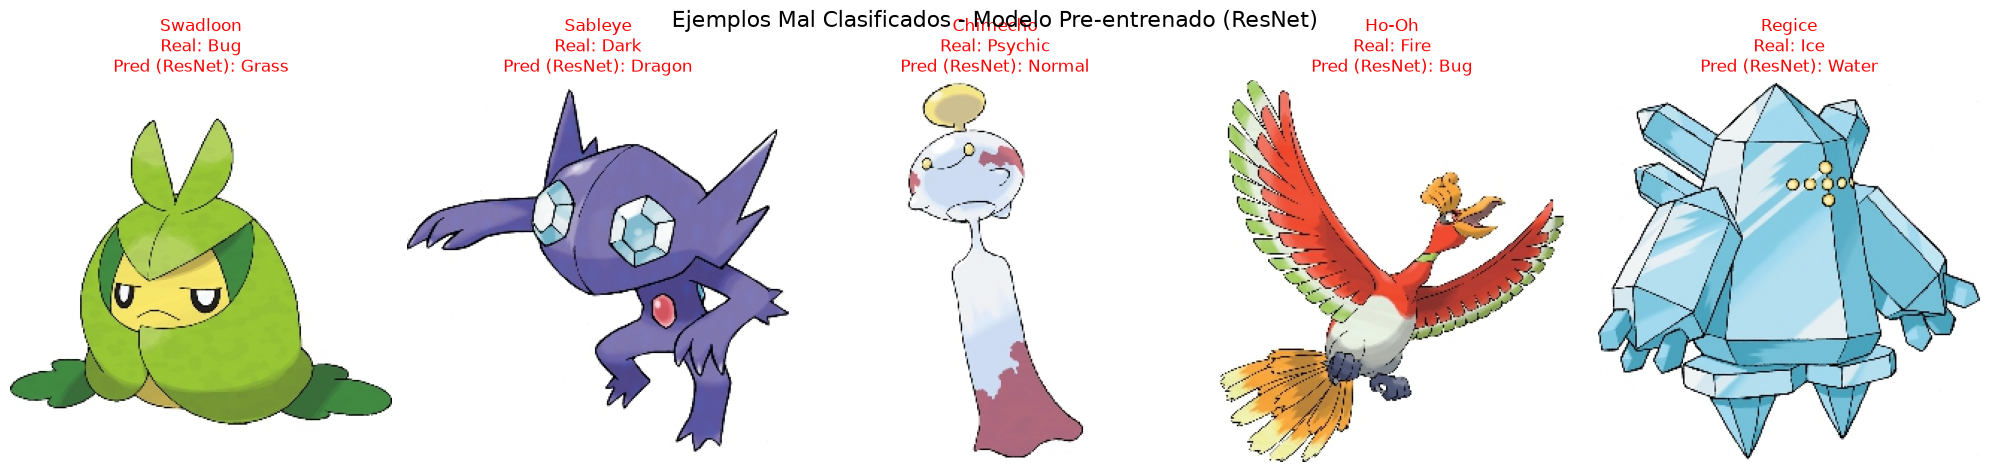

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Encontrar los índices donde el modelo pre-entrenado falló
# Usamos y_reales y y_predicciones que ya están definidas en la celda anterior
errores_idx_pre = np.where(np.array(y_reales) != np.array(y_predicciones))[0]
print(f"Total de errores (ResNet Pre-entrenada): {len(errores_idx_pre)} de {len(y_reales)}")

# Visualizar los primeros 5 ejemplos mal clasificados
num_errores_mostrar = min(5, len(errores_idx_pre))

if num_errores_mostrar > 0:
    fig, axes = plt.subplots(1, num_errores_mostrar, figsize=(4 * num_errores_mostrar, 5))
    
    # Si solo hay 1 error, axes no es un array, así que lo convertimos para iterar
    if num_errores_mostrar == 1:
        axes = [axes]

    for i, idx in enumerate(errores_idx_pre[:num_errores_mostrar]): 
        # Extraer los datos originales del test_dataset
        imagen_tensor, etiqueta_real, nombre, atributos = test_dataset[idx]
        prediccion = y_predicciones[idx]
        
        # Obtener el texto del tipo real y el predicho
        tipo_real = dataset.categories[etiqueta_real]
        tipo_predicho = dataset.categories[prediccion]
        
        # Las imágenes en PyTorch tienen shape (Canales, Alto, Ancho)
        # plt.imshow espera (Alto, Ancho, Canales), por lo que usamos permute()
        img_mostrar = imagen_tensor.permute(-2, -1, 0).cpu().numpy()
        
        # Mostrar la imagen
        axes[i].imshow(img_mostrar)
        axes[i].set_title(f"{nombre}\nReal: {tipo_real}\nPred (ResNet): {tipo_predicho}", fontsize=12, color='red')
        axes[i].axis('off')

    plt.suptitle("Ejemplos Mal Clasificados - Modelo Pre-entrenado (ResNet)", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("¡El modelo no tuvo ningún error en el conjunto de prueba!")

#### Resultados: Modelo Pre-entrenado + Aumentación

**1. Análisis de las Curvas de Aprendizaje:**
* **Convergencia y Estancamiento:** La pérdida de entrenamiento (línea azul) desciende de manera continua, demostrando que el modelo tiene la capacidad de aprender las representaciones. Sin embargo, la pérdida de validación (línea naranja) desciende rápidamente al principio pero **se estanca formando una meseta a partir de la época 15-17** (oscilando cerca de un valor de 2.0).
* **Efecto de la Regularización:** Aunque a partir de la época 15 el modelo alcanza su límite de generalización, la curva de validación no sufre un "rebote" explosivo hacia arriba como con otras arquitecturas.

**2. Análisis del Reporte de Clasificación:**
* **Rendimiento General:** El modelo alcanza una exactitud (*Accuracy*) global del **41%**. Considerando que el azar puro en un problema de 18 clases, la red ha logrado rescatar patrones visuales significativos a pesar de la limitación extrema de datos.
* **Casos de Éxito:** La arquitectura logró extraer características sólidas para los tipos **Lucha, Bicho, Planta y Electrico**, todos alcanzando *F1-scores* y *Recalls* del 60% o más. El tipo Agua, apoyado por su gran soporte (14 ejemplos), también mantiene un buen nivel de reconocimiento (64% de *Recall*).
* **Desafíos Persistentes:** A pesar de haber implementado la ponderación en la función de pérdida (`pesos_tensor`), la red sufre una caída total (*F1-score* de 0.00) en tipos como **Psíquico, Tierra, Dragón, Siniestro y Acero**. 

**Conclusión del Experimento:**
La integración de Transfer Learning (ResNet) mitigó en gran medida la dificultad del problema. El fracaso en las clases mencionadas se explica directamente por la escasez crítica de datos (la mayoría tiene solo entre 2 y 4 imágenes de prueba). El caso particular del tipo **Psíquico** (que a pesar de tener 7 ejemplos no obtuvo aciertos) sugiere que sus paletas de colores o formas geométricas son demasiado heterogéneas, provocando que la red las confunda con otras tipologías. Para futuras mejoras, este problema requeriría obligatoriamente una recolección de datos más robusta.